In [3]:
import pandas as pd
import os

# Carregar sua base já limpa
df = pd.read_csv('2025/base_senado_pronta_mineracao.csv', sep=';', encoding='utf-8')

# Agregar por departamento e mês para consolidar os gastos reais
df_depto = df.groupby(['LOTAÇÃO EXERCÍCIO', 'MES_REFERENCIA']).agg({
    'HORAS_EXTRAS': 'sum',
    'REMUN_BASICA': 'sum',
    'REM_LIQUIDA': 'sum',
    'FUNCAO_NUMERICA': 'mean', # Média hierárquica do setor
    'VÍNCULO': 'count'         # Quantidade de funcionários no setor
}).reset_index()

# Renomear coluna de contagem para representar o tamanho do departamento
df_depto.rename(columns={'VÍNCULO': 'QTD_SERVIDORES'}, inplace=True)

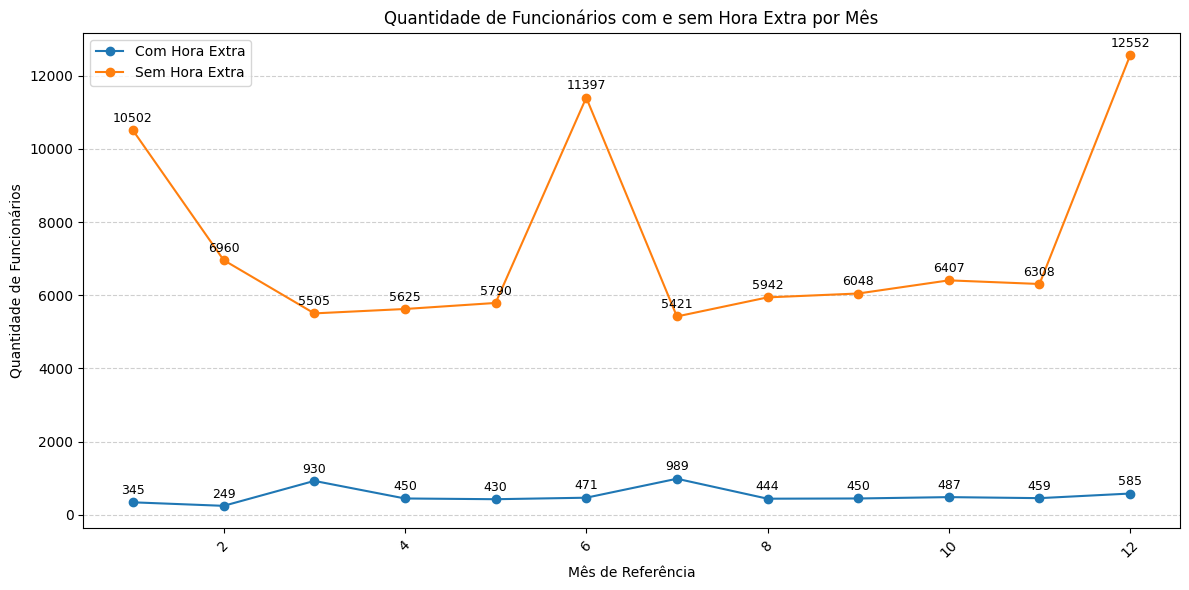

In [11]:
# Contagem mensal de funcionários com e sem hora extra
df['TEM_HORA_EXTRA'] = df['HORAS_EXTRAS'] > 0
contagem_mensal = (
    df.groupby(['MES_REFERENCIA', 'TEM_HORA_EXTRA'])['VÍNCULO']
      .count()
      .reset_index(name='QTD_FUNCIONARIOS')
)
contagem_mensal['TIPO'] = contagem_mensal['TEM_HORA_EXTRA'].map({True: 'Com Hora Extra', False: 'Sem Hora Extra'})
contagem_mensal = contagem_mensal.sort_values(['MES_REFERENCIA', 'TEM_HORA_EXTRA'])

plt.figure(figsize=(12,6))
for tipo, grupo in contagem_mensal.groupby('TIPO'):
    plt.plot(
        grupo['MES_REFERENCIA'],
        grupo['QTD_FUNCIONARIOS'],
        marker='o',
        label=tipo
    )
    for x, y in zip(grupo['MES_REFERENCIA'], grupo['QTD_FUNCIONARIOS']):
        plt.annotate(
            str(y),
            xy=(x, y),
            xytext=(0, 6),
            textcoords='offset points',
            ha='center',
            fontsize=9,
            color='black'
        )

plt.title('Quantidade de Funcionários com e sem Hora Extra por Mês')
plt.xlabel('Mês de Referência')
plt.ylabel('Quantidade de Funcionários')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [4]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Normalizar os dados (obrigatório para K-Means)
scaler = StandardScaler()
X = scaler.fit_transform(df_depto[['HORAS_EXTRAS', 'REMUN_BASICA', 'QTD_SERVIDORES']])

# Aplicar o K-Means (Exemplo com 3 grupos: Baixo Custo, Médio, Crítico)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_depto['CLUSTER_RISCO'] = kmeans.fit_predict(X)

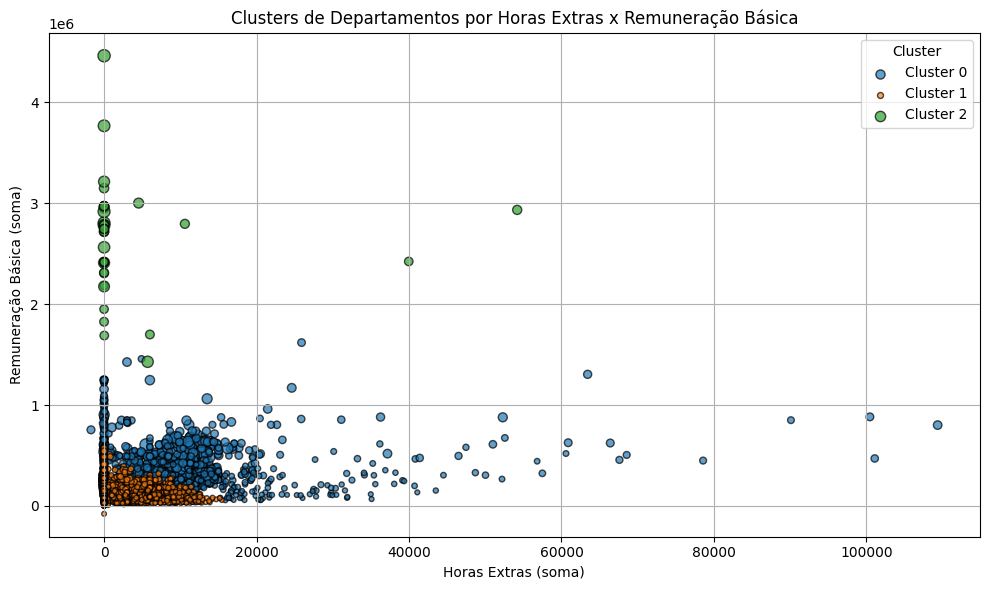

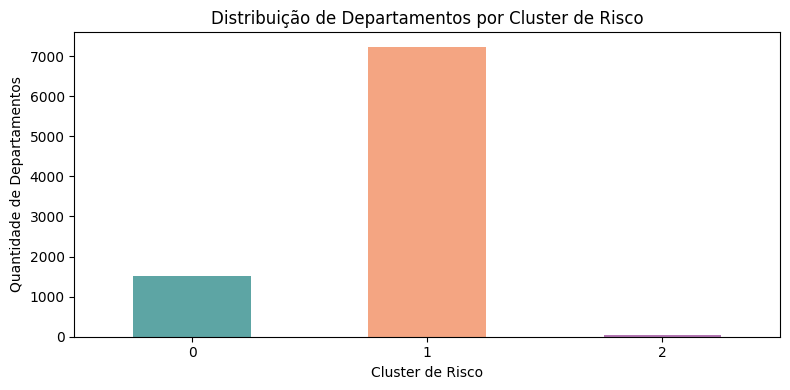

In [7]:
# Visualização dos clusters por departamento
plt.figure(figsize=(10,6))
for cluster in sorted(df_depto['CLUSTER_RISCO'].unique()):
    subset = df_depto[df_depto['CLUSTER_RISCO'] == cluster]
    plt.scatter(
        subset['HORAS_EXTRAS'],
        subset['REMUN_BASICA'],
        s=subset['QTD_SERVIDORES'] / 2 + 10,
        label=f'Cluster {cluster}',
        alpha=0.7,
        edgecolor='k'
    )

plt.title('Clusters de Departamentos por Horas Extras x Remuneração Básica')
plt.xlabel('Horas Extras (soma)')
plt.ylabel('Remuneração Básica (soma)')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
df_depto['CLUSTER_RISCO'].value_counts().sort_index().plot(
    kind='bar',
    color=['#5DA5A4', '#F4A582', '#B276B2']
)
plt.title('Distribuição de Departamentos por Cluster de Risco')
plt.xlabel('Cluster de Risco')
plt.ylabel('Quantidade de Departamentos')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
# Criar categorias para o Apriori
zero_mask = df['HORAS_EXTRAS'] == 0
positive = df.loc[~zero_mask, 'HORAS_EXTRAS']

df.loc[zero_mask, 'FAIXA_HORA_EXTRA'] = 'Zero/Baixa'

if not positive.empty:
    df.loc[~zero_mask, 'FAIXA_HORA_EXTRA'] = pd.qcut(
        positive,
        q=[0, 0.7, 0.9, 1.0],
        labels=['Média', 'Alta', 'Muito_Alta'],
        duplicates='drop'
    )

df['PERFIL_FUNCAO'] = df['FUNCAO_NUMERICA'].map({0: 'Sem_Funcao', 1: 'Funcao_Baixa', 2: 'Funcao_Baixa', 3: 'Funcao_Media', 4: 'Funcao_Alta', 5: 'Funcao_Alta'})

In [8]:
from mlxtend.frequent_patterns import apriori, association_rules

# Criar a matriz de transações (One-Hot Encoding das categorias)
df_associa = pd.get_dummies(df[['VÍNCULO', 'PERFIL_FUNCAO', 'FAIXA_HORA_EXTRA']])

# Encontrar itens frequentes e gerar as regras
itens_frequentes = apriori(df_associa, min_support=0.05, use_colnames=True)
regras = association_rules(itens_frequentes, metric="confidence", min_threshold=0.6)

# Filtrar regras onde a consequência é ter Hora Extra Alta
regras_criticas = regras[regras['consequents'].astype(str).str.contains('FAIXA_HORA_EXTRA_Alta')]

In [9]:
# Visualizar as regras de associação críticas
if not regras_criticas.empty:
    regras_criticas = regras_criticas.sort_values(by='confidence', ascending=False).reset_index(drop=True)
    top_regras = regras_criticas.head(10)

    plt.figure(figsize=(10,6))
    plt.barh(
        top_regras.index,
        top_regras['confidence'],
        color='#4C72B0'
    )
    plt.yticks(
        top_regras.index,
        top_regras['antecedents'].astype(str) + ' → ' + top_regras['consequents'].astype(str)
    )
    plt.gca().invert_yaxis()
    plt.xlabel('Confiança')
    plt.title('Top 10 Regras de Associação com Hora Extra Alta')
    plt.tight_layout()
    plt.show()
else:
    print('Não há regras críticas encontradas para Hora Extra Alta.')

Não há regras críticas encontradas para Hora Extra Alta.
